# This is to test on pilot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

In [3]:

# ============================================================
# 1. Configuration
# ============================================================

@dataclass
class OFDMPilotConfig:
    fs: int = 48000
    nfft: int = 1024
    cp_len: int = 128

    # Keep away from very low and very high audio frequencies.
    f_min: float = 1000.0
    f_max: float = 10000.0

    # Every pilot_spacing-th active subcarrier is a pilot.
    pilot_spacing: int = 8

    # Random seeds must be shared by transmitter and receiver.
    comb_pilot_seed: int = 123
    full_pilot_seed: int = 999


In [4]:


# ============================================================
# 2. Subcarrier allocation
# ============================================================

def get_subcarrier_allocation(cfg: OFDMPilotConfig):
    """
    Choose positive-frequency active bins for real-valued audio OFDM.
    Negative-frequency bins are filled by Hermitian symmetry automatically.
    """
    positive_bins = np.arange(1, cfg.nfft // 2)
    freqs = positive_bins * cfg.fs / cfg.nfft

    active_bins = positive_bins[(freqs >= cfg.f_min) & (freqs <= cfg.f_max)]
    pilot_bins = active_bins[::cfg.pilot_spacing]
    data_bins = np.setdiff1d(active_bins, pilot_bins)

    if len(active_bins) == 0:
        raise ValueError("No active bins. Check f_min, f_max, fs, and nfft.")
    if len(pilot_bins) == 0:
        raise ValueError("No pilot bins. Reduce pilot_spacing or widen frequency band.")
    if len(data_bins) == 0:
        raise ValueError("No data bins. Increase active band or pilot_spacing.")

    return active_bins, pilot_bins, data_bins


def make_bpsk_pilots(num_pilots: int, seed: int):
    """
    Fixed BPSK pilots. Tx and Rx must use the same seed.
    """
    rng = np.random.default_rng(seed)
    bits = rng.integers(0, 2, size=num_pilots)
    return (2 * bits - 1).astype(complex)



In [5]:


# ============================================================
# 3. QPSK modulator and demodulator
# ============================================================

def qpsk_mod(bits):
    """
    Simple QPSK mapping:
        bit 0 controls real sign
        bit 1 controls imag sign

    00 -> +1 + j
    01 -> +1 - j
    10 -> -1 + j
    11 -> -1 - j
    """
    bits = np.asarray(bits).astype(int)
    original_num_bits = len(bits)

    pad_bits = 0
    if len(bits) % 2 != 0:
        bits = np.concatenate([bits, np.array([0])])
        pad_bits = 1

    pairs = bits.reshape(-1, 2)
    real = 1 - 2 * pairs[:, 0]
    imag = 1 - 2 * pairs[:, 1]
    symbols = (real + 1j * imag) / np.sqrt(2)

    return symbols, original_num_bits, pad_bits


def qpsk_demod(symbols):
    """
    Hard-decision QPSK demodulator matching qpsk_mod().
    """
    symbols = np.asarray(symbols)
    bits = np.zeros(2 * len(symbols), dtype=int)
    bits[0::2] = (symbols.real < 0).astype(int)
    bits[1::2] = (symbols.imag < 0).astype(int)
    return bits

In [6]:

# ============================================================
# 4. OFDM symbol generation
# ============================================================

def ifft_real_with_cp(X, cfg: OFDMPilotConfig):
    """
    Convert frequency-domain OFDM bins into a real time-domain symbol.
    Assumes X already has Hermitian symmetry.
    """
    x = np.fft.ifft(X).real
    x_cp = np.concatenate([x[-cfg.cp_len:], x])
    return x_cp


def remove_cp_and_fft(rx_symbol_cp, cfg: OFDMPilotConfig):
    """
    Remove cyclic prefix and take FFT.
    """
    if len(rx_symbol_cp) < cfg.nfft + cfg.cp_len:
        raise ValueError("Received symbol is too short.")

    x = rx_symbol_cp[cfg.cp_len : cfg.cp_len + cfg.nfft]
    return np.fft.fft(x)


def make_full_pilot_symbol(cfg: OFDMPilotConfig, active_bins):
    """
    One OFDM symbol where all active bins are known pilots.
    This is used for initial channel estimation.
    """
    full_pilot_values = make_bpsk_pilots(len(active_bins), cfg.full_pilot_seed)

    X = np.zeros(cfg.nfft, dtype=complex)
    X[active_bins] = full_pilot_values
    X[-active_bins] = np.conj(full_pilot_values)

    x_cp = ifft_real_with_cp(X, cfg)
    return x_cp, full_pilot_values


def make_data_symbol_with_comb_pilots(
    data_symbols,
    cfg: OFDMPilotConfig,
    data_bins,
    pilot_bins,
    comb_pilot_values,
):
    """
    One OFDM data symbol with pilot subcarriers inserted.
    """
    if len(data_symbols) != len(data_bins):
        raise ValueError("data_symbols length must equal len(data_bins).")

    X = np.zeros(cfg.nfft, dtype=complex)

    # Positive-frequency side.
    X[data_bins] = data_symbols
    X[pilot_bins] = comb_pilot_values

    # Negative-frequency side for real-valued audio.
    X[-data_bins] = np.conj(data_symbols)
    X[-pilot_bins] = np.conj(comb_pilot_values)

    x_cp = ifft_real_with_cp(X, cfg)
    return x_cp


In [8]:


# ============================================================
# 5. Transmitter frame builder
# ============================================================

def build_tx_frame(bits, cfg: OFDMPilotConfig):
    """
    Build a complete pilot-based OFDM frame.

    Frame structure:
        [full-pilot OFDM symbol]
        [data OFDM symbol 0 with comb pilots]
        [data OFDM symbol 1 with comb pilots]
        ...

    This testbed intentionally does not include chirp sync yet.
    We assume frame start is known. Later can put your chirp before this frame.
    """
    active_bins, pilot_bins, data_bins = get_subcarrier_allocation(cfg)
    comb_pilot_values = make_bpsk_pilots(len(pilot_bins), cfg.comb_pilot_seed)

    qpsk_symbols, original_num_bits, qpsk_pad_bits = qpsk_mod(bits)

    n_data_per_symbol = len(data_bins)
    n_data_symbols = int(np.ceil(len(qpsk_symbols) / n_data_per_symbol))
    qpsk_symbol_pad = n_data_symbols * n_data_per_symbol - len(qpsk_symbols)

    if qpsk_symbol_pad > 0:
        qpsk_symbols_padded = np.concatenate([
            qpsk_symbols,
            np.zeros(qpsk_symbol_pad, dtype=complex),
        ])
    else:
        qpsk_symbols_padded = qpsk_symbols

    full_pilot_symbol, full_pilot_values = make_full_pilot_symbol(cfg, active_bins)

    data_time_symbols = []
    for i in range(n_data_symbols):
        block = qpsk_symbols_padded[i * n_data_per_symbol : (i + 1) * n_data_per_symbol]
        x_cp = make_data_symbol_with_comb_pilots(
            block,
            cfg,
            data_bins,
            pilot_bins,
            comb_pilot_values,
        )
        data_time_symbols.append(x_cp)

    tx = np.concatenate([full_pilot_symbol] + data_time_symbols)

    # Normalise to prevent clipping when saving or playing as audio.
    peak = np.max(np.abs(tx)) + 1e-12
    tx = 0.8 * tx / peak

    ref = {
        "original_num_bits": original_num_bits,
        "qpsk_pad_bits": qpsk_pad_bits,
        "qpsk_symbol_pad": qpsk_symbol_pad,
        "num_data_symbols": n_data_symbols,
        "tx_qpsk_symbols": qpsk_symbols,
        "active_bins": active_bins,
        "pilot_bins": pilot_bins,
        "data_bins": data_bins,
        "comb_pilot_values": comb_pilot_values,
        "full_pilot_values": full_pilot_values,
        "symbol_len": cfg.nfft + cfg.cp_len,
    }

    return tx, ref

In [9]:



# ============================================================
# 6. Channel models for testing
# ============================================================

def add_awgn(x, snr_db, seed=0):
    """
    Add white Gaussian noise at a target SNR.
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    power = np.mean(x ** 2)
    noise_power = power / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_power), size=len(x))
    return x + noise


def add_echo(x, delay_samples=80, gain=0.4):
    """
    Simple single-echo channel.
    If delay_samples is smaller than CP length, OFDM should handle it better.
    """
    y = np.copy(x)
    if delay_samples <= 0:
        return y
    y[delay_samples:] += gain * x[:-delay_samples]
    return y


def apply_fractional_delay(x, delay_samples):
    """
    Apply a fractional sample delay using linear interpolation.
    Positive delay means the received signal starts later.
    """
    n = np.arange(len(x))
    return np.interp(n - delay_samples, n, x, left=0.0, right=0.0)


def apply_sampling_rate_mismatch(x, ppm):
    """
    Simulate sampling-rate mismatch using interpolation.

    ppm > 0 means receiver sampling clock is slightly faster.
    This creates slow timing drift across OFDM symbols.
    """
    x = np.asarray(x)
    factor = 1.0 + ppm * 1e-6

    old_n = np.arange(len(x))
    new_n = np.arange(len(x)) * factor

    y = np.interp(new_n, old_n, x, left=0.0, right=0.0)
    return y


In [10]:


# ============================================================
# 7. Receiver correction methods
# ============================================================

def estimate_initial_channel_from_full_pilot(rx_full_pilot_cp, cfg, active_bins, full_pilot_values):
    """
    Estimate channel response on all active bins using the full-pilot OFDM symbol.
    """
    Y = remove_cp_and_fft(rx_full_pilot_cp, cfg)
    H_active = Y[active_bins] / (full_pilot_values + 1e-12)
    return H_active


def interpolate_channel(active_bins, H_active, target_bins):
    """
    Linear interpolation of the complex channel estimate.
    In this testbed H_active is already available on all active bins,
    so this function mostly keeps the interface clean.
    """
    real = np.interp(target_bins, active_bins, H_active.real)
    imag = np.interp(target_bins, active_bins, H_active.imag)
    return real + 1j * imag


def correct_common_phase_only(
    Y,
    cfg,
    active_bins,
    pilot_bins,
    comb_pilot_values,
    H_active,
):
    """
    Use comb pilots to estimate and correct one common phase error per OFDM symbol.
    """
    H_pilots = interpolate_channel(active_bins, H_active, pilot_bins)

    residual = Y[pilot_bins] / (H_pilots * comb_pilot_values + 1e-12)
    cpe = np.angle(np.mean(residual))

    Y_corr = Y.copy()
    Y_corr[active_bins] *= np.exp(-1j * cpe)

    debug = {
        "cpe": cpe,
        "slope": 0.0,
        "intercept": cpe,
        "timing_offset_est": 0.0,
        "pilot_phase": np.unwrap(np.angle(residual)),
    }
    return Y_corr, debug


def correct_phase_slope(
    Y,
    cfg,
    active_bins,
    pilot_bins,
    comb_pilot_values,
    H_active,
):
    """
    Use comb pilots to estimate a linear phase model:
        residual_phase(k) = slope * k + intercept

    intercept handles common phase error.
    slope handles timing offset / sampling drift.
    """
    H_pilots = interpolate_channel(active_bins, H_active, pilot_bins)

    residual = Y[pilot_bins] / (H_pilots * comb_pilot_values + 1e-12)
    phase = np.unwrap(np.angle(residual))

    slope, intercept = np.polyfit(pilot_bins, phase, 1)

    correction_phase = slope * active_bins + intercept

    Y_corr = Y.copy()
    Y_corr[active_bins] *= np.exp(-1j * correction_phase)

    # If a time-domain timing offset is tau samples, frequency-domain phase is
    # approximately -2*pi*k*tau/NFFT. Therefore tau is approximately:
    timing_offset_est = -slope * cfg.nfft / (2 * np.pi)

    debug = {
        "cpe": intercept,
        "slope": slope,
        "intercept": intercept,
        "timing_offset_est": timing_offset_est,
        "pilot_phase": phase,
    }
    return Y_corr, debug


# ============================================================
# 8. Receiver decoder
# ============================================================

def decode_rx_frame(rx, cfg: OFDMPilotConfig, ref, mode="phase_slope"):
    """
    Decode a received frame with different pilot modes.

    Available modes:
        no_correction
        channel_only
        common_phase
        phase_slope
    """
    active_bins = ref["active_bins"]
    pilot_bins = ref["pilot_bins"]
    data_bins = ref["data_bins"]
    full_pilot_values = ref["full_pilot_values"]
    comb_pilot_values = ref["comb_pilot_values"]
    n_data_symbols = ref["num_data_symbols"]
    symbol_len = ref["symbol_len"]

    needed_len = (1 + n_data_symbols) * symbol_len
    if len(rx) < needed_len:
        raise ValueError(
            f"rx is too short. Need at least {needed_len} samples, got {len(rx)}."
        )

    rx_full_pilot_cp = rx[:symbol_len]

    # Channel estimate from the full-pilot symbol.
    if mode == "no_correction":
        H_active = np.ones(len(active_bins), dtype=complex)
    else:
        H_active = estimate_initial_channel_from_full_pilot(
            rx_full_pilot_cp,
            cfg,
            active_bins,
            full_pilot_values,
        )

    all_data_est = []
    cpe_list = []
    slope_list = []
    timing_offset_list = []
    pilot_phase_list = []

    for i in range(n_data_symbols):
        start = (1 + i) * symbol_len
        end = start + symbol_len
        rx_symbol_cp = rx[start:end]

        Y = remove_cp_and_fft(rx_symbol_cp, cfg)

        if mode == "no_correction":
            Y_corr = Y
            debug = {
                "cpe": 0.0,
                "slope": 0.0,
                "timing_offset_est": 0.0,
                "pilot_phase": np.zeros(len(pilot_bins)),
            }
        elif mode == "channel_only":
            Y_corr = Y
            debug = {
                "cpe": 0.0,
                "slope": 0.0,
                "timing_offset_est": 0.0,
                "pilot_phase": np.zeros(len(pilot_bins)),
            }
        elif mode == "common_phase":
            Y_corr, debug = correct_common_phase_only(
                Y,
                cfg,
                active_bins,
                pilot_bins,
                comb_pilot_values,
                H_active,
            )
        elif mode == "phase_slope":
            Y_corr, debug = correct_phase_slope(
                Y,
                cfg,
                active_bins,
                pilot_bins,
                comb_pilot_values,
                H_active,
            )
        else:
            raise ValueError(f"Unknown mode: {mode}")

        H_data = interpolate_channel(active_bins, H_active, data_bins)
        data_est = Y_corr[data_bins] / (H_data + 1e-12)
        all_data_est.append(data_est)

        cpe_list.append(debug["cpe"])
        slope_list.append(debug["slope"])
        timing_offset_list.append(debug["timing_offset_est"])
        pilot_phase_list.append(debug["pilot_phase"])

    rx_qpsk_symbols = np.concatenate(all_data_est)

    # Remove symbol padding added at the transmitter.
    qpsk_symbol_pad = ref["qpsk_symbol_pad"]
    if qpsk_symbol_pad > 0:
        rx_qpsk_symbols = rx_qpsk_symbols[:-qpsk_symbol_pad]

    rx_bits = qpsk_demod(rx_qpsk_symbols)
    rx_bits = rx_bits[: ref["original_num_bits"]]

    debug_info = {
        "H_active": H_active,
        "cpe": np.array(cpe_list),
        "slope": np.array(slope_list),
        "timing_offset_est": np.array(timing_offset_list),
        "pilot_phase": pilot_phase_list,
    }

    return rx_qpsk_symbols, rx_bits, debug_info


# ============================================================
# 9. Metrics and plotting
# ============================================================

def compute_ber(tx_bits, rx_bits):
    n = min(len(tx_bits), len(rx_bits))
    if n == 0:
        return np.nan
    return np.mean(np.asarray(tx_bits[:n]).astype(int) != np.asarray(rx_bits[:n]).astype(int))


def compute_evm(tx_symbols, rx_symbols):
    n = min(len(tx_symbols), len(rx_symbols))
    tx = tx_symbols[:n]
    rx = rx_symbols[:n]
    evm = np.sqrt(np.mean(np.abs(rx - tx) ** 2) / (np.mean(np.abs(tx) ** 2) + 1e-12))
    evm_db = 20 * np.log10(evm + 1e-12)
    return evm, evm_db


def plot_constellation(symbols, title, max_points=5000):
    symbols = np.asarray(symbols)
    if len(symbols) > max_points:
        symbols = symbols[:max_points]

    plt.figure(figsize=(5, 5))
    plt.scatter(symbols.real, symbols.imag, s=6, alpha=0.5)
    plt.axhline(0, linewidth=0.7)
    plt.axvline(0, linewidth=0.7)
    plt.grid(True)
    plt.axis("equal")
    plt.xlabel("In-phase")
    plt.ylabel("Quadrature")
    plt.title(title)
    plt.show()


def plot_debug_curves(debug_info, title_prefix=""):
    plt.figure(figsize=(8, 4))
    plt.plot(debug_info["cpe"])
    plt.grid(True)
    plt.xlabel("OFDM symbol index")
    plt.ylabel("Phase / rad")
    plt.title(title_prefix + "Common phase estimate")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(debug_info["timing_offset_est"])
    plt.grid(True)
    plt.xlabel("OFDM symbol index")
    plt.ylabel("Samples")
    plt.title(title_prefix + "Estimated timing offset from pilot phase slope")
    plt.show()


def plot_one_symbol_pilot_phase(debug_info, ref, symbol_index=0, title="Residual pilot phase"):
    pilot_bins = ref["pilot_bins"]
    phase = debug_info["pilot_phase"][symbol_index]

    plt.figure(figsize=(7, 4))
    plt.plot(pilot_bins, phase, "o-")
    plt.grid(True)
    plt.xlabel("Pilot subcarrier index")
    plt.ylabel("Phase / rad")
    plt.title(title)
    plt.show()


# ============================================================
# 10. Complete experiment runner
# ============================================================

def run_one_experiment(channel_name="echo_noise", show_plots=True):
    cfg = OFDMPilotConfig(
        fs=48000,
        nfft=1024,
        cp_len=128,
        f_min=1000,
        f_max=10000,
        pilot_spacing=8,
    )

    rng = np.random.default_rng(2026)
    tx_bits = rng.integers(0, 2, size=8000)

    tx, ref = build_tx_frame(tx_bits, cfg)

    print("=== OFDM pilot testbed ===")
    print("NFFT:", cfg.nfft)
    print("CP length:", cfg.cp_len)
    print("Active bins:", len(ref["active_bins"]))
    print("Pilot bins:", len(ref["pilot_bins"]))
    print("Data bins:", len(ref["data_bins"]))
    print("Data OFDM symbols:", ref["num_data_symbols"])
    print("Frame samples:", len(tx))
    print()

    # Choose a simulated channel.
    if channel_name == "clean":
        rx = tx.copy()
    elif channel_name == "noise":
        rx = add_awgn(tx, snr_db=20, seed=1)
    elif channel_name == "echo":
        rx = add_echo(tx, delay_samples=80, gain=0.45)
    elif channel_name == "echo_noise":
        rx = add_echo(tx, delay_samples=80, gain=0.45)
        rx = add_awgn(rx, snr_db=20, seed=1)
    elif channel_name == "timing_offset":
        rx = apply_fractional_delay(tx, delay_samples=3.4)
        rx = add_awgn(rx, snr_db=25, seed=1)
    elif channel_name == "sampling_mismatch":
        rx = add_echo(tx, delay_samples=80, gain=0.35)
        rx = apply_sampling_rate_mismatch(rx, ppm=120)
        rx = add_awgn(rx, snr_db=25, seed=1)
    else:
        raise ValueError(f"Unknown channel_name: {channel_name}")

    modes = [
        "no_correction",
        "channel_only",
        "common_phase",
        "phase_slope",
    ]

    results = {}

    for mode in modes:
        rx_syms, rx_bits, debug = decode_rx_frame(rx, cfg, ref, mode=mode)
        ber = compute_ber(tx_bits, rx_bits)
        evm, evm_db = compute_evm(ref["tx_qpsk_symbols"], rx_syms)

        results[mode] = {
            "rx_syms": rx_syms,
            "rx_bits": rx_bits,
            "debug": debug,
            "ber": ber,
            "evm": evm,
            "evm_db": evm_db,
        }

        print(f"Mode: {mode}")
        print(f"  BER:    {ber:.6f}")
        print(f"  EVM:    {evm:.6f}")
        print(f"  EVM dB: {evm_db:.2f} dB")
        print()

    if show_plots:
        for mode in modes:
            plot_constellation(results[mode]["rx_syms"], f"Constellation: {mode}")

        plot_debug_curves(results["phase_slope"]["debug"], title_prefix="Phase-slope mode: ")
        plot_one_symbol_pilot_phase(
            results["phase_slope"]["debug"],
            ref,
            symbol_index=0,
            title="Residual pilot phase before phase-slope correction, symbol 0",
        )

    return results, tx, rx, ref, cfg




=== OFDM pilot testbed ===
NFFT: 1024
CP length: 128
Active bins: 192
Pilot bins: 24
Data bins: 168
Data OFDM symbols: 24
Frame samples: 28800

Mode: no_correction
  BER:    0.000000
  EVM:    11.049679
  EVM dB: 20.87 dB

Mode: channel_only
  BER:    0.000000
  EVM:    0.099724
  EVM dB: -20.02 dB

Mode: common_phase
  BER:    0.000000
  EVM:    0.100867
  EVM dB: -19.93 dB

Mode: phase_slope
  BER:    0.000000
  EVM:    0.101854
  EVM dB: -19.84 dB



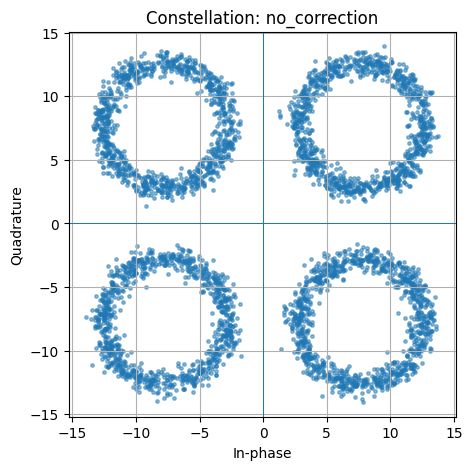

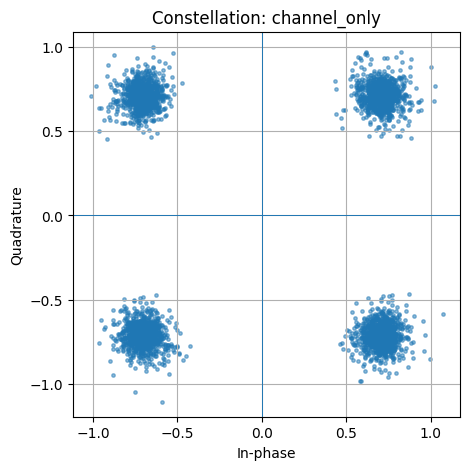

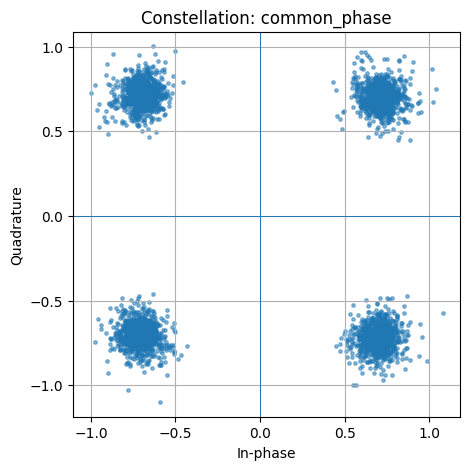

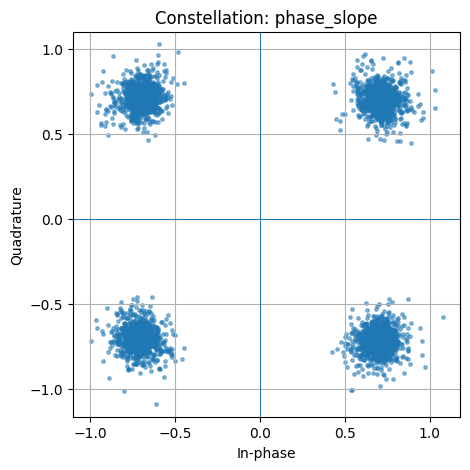

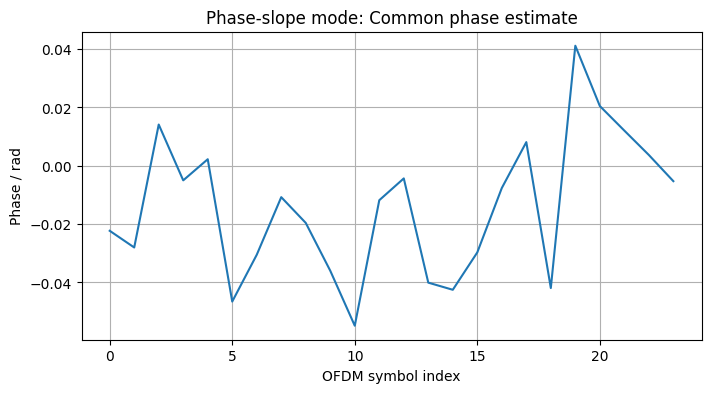

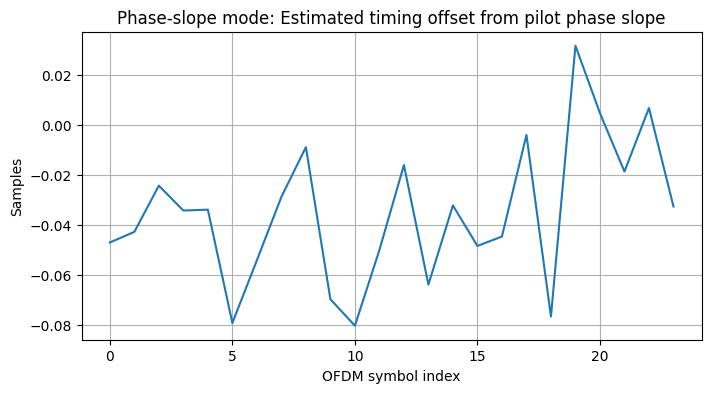

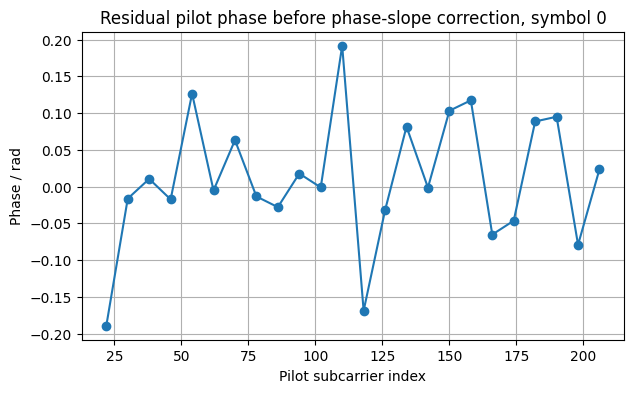

In [12]:

if __name__ == "__main__":
    # Try these channel names:
    #   clean
    #   noise
    #   echo
    #   echo_noise
    #   timing_offset
    #   sampling_mismatch
    run_one_experiment(channel_name="echo_noise", show_plots=True)

In [ ]:

# ============================================================
# Sampling Mismatch Study: Pilot Spacing vs Tolerance
# ============================================================

def run_sampling_mismatch_sweep():
    """
    Test how pilot spacing affects tolerance to sampling mismatch.
    Measures BER across different sampling mismatches (in ppm) and pilot spacings.
    """
    import matplotlib.pyplot as plt
    
    # Test parameters
    pilot_spacings = [4, 6, 8, 12, 16]  # Number of subcarriers between pilots
    sampling_mismatches_ppm = np.linspace(0, 300, 16)  # 0 to 300 ppm
    
    results = {}
    
    for pilot_spacing in pilot_spacings:
        ber_list = []
        
        for ppm in sampling_mismatches_ppm:
            # Create config with specific pilot spacing
            cfg = OFDMPilotConfig(
                fs=48000,
                nfft=1024,
                cp_len=128,
                f_min=1000,
                f_max=10000,
                pilot_spacing=pilot_spacing,
            )
            
            rng = np.random.default_rng(2026)
            tx_bits = rng.integers(0, 2, size=8000)
            
            tx, ref = build_tx_frame(tx_bits, cfg)
            
            # Apply sampling mismatch
            rx = add_echo(tx, delay_samples=80, gain=0.35)
            rx = apply_sampling_rate_mismatch(rx, ppm=ppm)
            rx = add_awgn(rx, snr_db=25, seed=1)
            
            # Decode with phase-slope correction
            rx_syms, rx_bits, debug = decode_rx_frame(rx, cfg, ref, mode="phase_slope")
            ber = compute_ber(tx_bits, rx_bits)
            ber_list.append(ber)
        
        results[pilot_spacing] = ber_list
        print(f"Pilot spacing {pilot_spacing}: done")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    for pilot_spacing in pilot_spacings:
        plt.plot(sampling_mismatches_ppm, results[pilot_spacing], 
                marker='o', label=f"Spacing={pilot_spacing}")
    
    plt.xlabel("Sampling Mismatch (ppm)")
    plt.ylabel("Bit Error Rate")
    plt.title("Pilot Spacing vs Sampling Mismatch Tolerance")
    plt.grid(True)
    plt.legend()
    plt.yscale('log')
    plt.show()
    
    # Summary
    print("\n=== SAMPLING MISMATCH TOLERANCE ===")
    print("(PPM where BER exceeds 1e-2)\n")
    for pilot_spacing in pilot_spacings:
        bers = results[pilot_spacing]
        # Find PPM threshold where BER > 1e-2
        threshold_idx = next((i for i, ber in enumerate(bers) if ber > 1e-2), None)
        if threshold_idx is not None:
            threshold_ppm = sampling_mismatches_ppm[threshold_idx]
        else:
            threshold_ppm = sampling_mismatches_ppm[-1]  # Didn't exceed threshold
        print(f"Pilot spacing {pilot_spacing:2d}: tolerates up to ~{threshold_ppm:.1f} ppm")
    
    return results, sampling_mismatches_ppm

# Run the sweep
results_sweep, ppm_values = run_sampling_mismatch_sweep()